# GloFAS absolute timeseries

In [80]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from src.constants import *
from src.datasources import glofas

In [83]:
ref_ens = glofas.load_reforecast_ensembles()
ref = (
    ref_ens.groupby(["time", "valid_time"])[["dis24", "leadtime"]]
    .mean()
    .reset_index()
)
ref["leadtime"] = ref["leadtime"].astype(int)
max_complete_lt = 45
ref = ref[ref["leadtime"] <= max_complete_lt]

In [84]:
ref

,time,valid_time,dis24,leadtime
0,2003-06-01,2003-06-02,177.359375,1
1,2003-06-01,2003-06-03,175.403122,2
2,2003-06-01,2003-06-04,173.890625,3
3,2003-06-01,2003-06-05,173.784378,4
4,2003-06-01,2003-06-06,172.512497,5
...,...,...,...,...
68510,2022-11-30,2023-01-10,142.311722,41
68511,2022-11-30,2023-01-11,139.352341,42
68512,2022-11-30,2023-01-12,136.464844,43
68513,2022-11-30,2023-01-13,133.656250,44


In [85]:
rp_a = 5

rea = glofas.load_reanalysis()
rea = rea[rea["time"].dt.year.isin(ref["time"].dt.year.unique())]
rea_peaks = rea.loc[rea.groupby(rea["time"].dt.year)["dis24"].idxmax()]
q_rp_a = rea_peaks["dis24"].quantile(1 - 1 / rp_a)
rea_peaks["trigger"] = rea_peaks["dis24"] > q_rp_a
rea_peaks["year"] = rea_peaks["time"].dt.year
rea_peaks["cerf"] = rea_peaks["year"].isin(CERF_YEARS)
rea_peaks["rank"] = rea_peaks["dis24"].rank(ascending=False)
rea_peaks["rp"] = len(rea_peaks) / rea_peaks["rank"]
rea_peaks.sort_values("rank")

,time,dis24,trigger,year,cerf,rank,rp
2819,2010-09-20,6714.9453,True,2010,False,1.0,20.000000
7208,2022-09-26,6254.0547,True,2022,True,2.0,10.000000
257,2003-09-15,6072.0000,True,2003,False,3.0,6.666667
3547,2012-09-17,5551.9844,True,2012,True,4.0,5.000000
1003,2005-09-30,4930.1953,False,2005,False,5.0,4.000000
6471,2020-09-19,3401.8203,False,2020,False,6.0,3.333333
5734,2018-09-13,3318.6250,False,2018,False,7.0,2.857143
1357,2006-09-19,3277.3750,False,2006,False,8.0,2.500000
1718,2007-09-15,3096.8672,False,2007,False,9.0,2.222222
6148,2019-11-01,2774.6250,False,2019,False,10.0,2.000000


In [100]:
rp_f = 5
lt_min = 5
LT_MAX = 45

val_col = "dis24"

dfs = []
dfs_threshs = []

for lt in ref["leadtime"].unique():
    if lt < lt_min or lt >= LT_MAX:
        continue

    dff = ref[(ref["leadtime"] <= lt) & (ref["leadtime"] >= lt_min)]
    df_in = dff.loc[dff.groupby(dff["time"].dt.year)[val_col].idxmax()]
    df_in["lt_max"] = lt
    thresh = df_in[val_col].quantile(1 - 1 / rp_f)
    df_in["trigger"] = df_in[val_col] >= thresh
    # print(lt, thresh)
    dfs_threshs.append({"lt_max": lt, "thresh": thresh})
    dfs.append(df_in)

ref_threshs = pd.DataFrame(dfs_threshs)
ref_peaks = pd.concat(dfs, ignore_index=True)
ref_peaks["year"] = ref_peaks["time"].dt.year

In [101]:
compare = (
    ref.drop(columns=["time"])
    .rename(columns={"valid_time": "time"})
    .merge(rea, on="time", suffixes=("_f", "_a"))
    .merge(ref_threshs.rename(columns={"lt_max": "leadtime"}))
)
compare["P"] = compare["dis24_a"] > q_rp_a
compare["PP"] = compare["dis24_f"] > compare["thresh"]
compare["TP"] = compare["P"] & compare["PP"]
compare["TN"] = ~compare["P"] & ~compare["PP"]
compare["FP"] = ~compare["P"] & compare["PP"]
compare["FN"] = compare["P"] & ~compare["PP"]

In [102]:
metrics = (
    compare.drop(columns=["time", "dis24_f", "dis24_a", "thresh"])
    .groupby("leadtime")
    .sum()
    .reset_index()
)
metrics["TPR"] = metrics["TP"] / metrics["P"]
metrics["PPV"] = metrics["TP"] / metrics["PP"]

<Axes: xlabel='leadtime'>

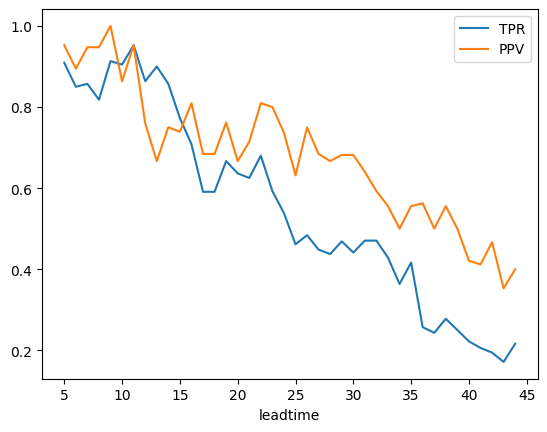

In [103]:
metrics.plot(x="leadtime", y=["TPR", "PPV"])

<Axes: xlabel='leadtime'>

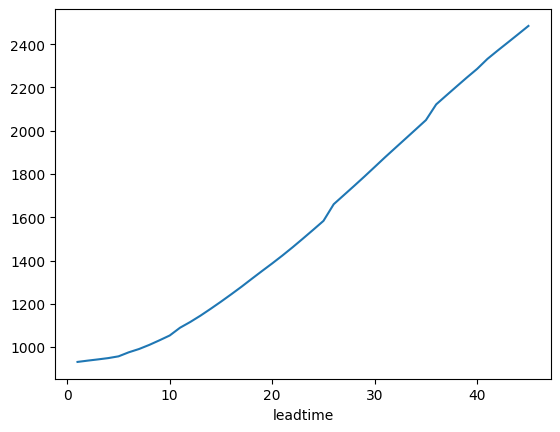

In [94]:
ref.groupby("leadtime")["dis24"].mean().plot()

In [95]:
ref.groupby("valid_time").size().max()

26

In [96]:
ref = (
    ref.groupby("valid_time")
    .apply(identify_complete_valid_times, include_groups=False)
    .reset_index(level=0)
)

In [97]:
ref["complete"].mean()

0.02167408596657666

In [98]:
def identify_complete_valid_times(group):
    group["complete"] = len(group) == 15
    return group

<Axes: xlabel='leadtime'>

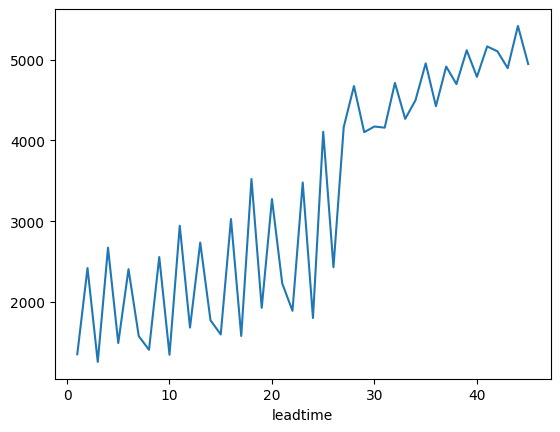

In [99]:
ref[ref["complete"]].groupby("leadtime")["dis24"].mean().plot()